# 01 — Exploración de datos

**Proyecto:** AchachAI — Detector de posibles fraudes en siniestros vehiculares  
**Reto:** Aseguradora del Sur · hackIAthon 2026

Este notebook explora las 7 tablas normalizadas en `data/processed/` y valida que las **14 señales** y **7 reglas críticas** del reto son detectables en el dataset. También deja gráficos listos para el pitch.

**Requisito previo:** haber corrido en este orden:
```bash
python scripts/clean_dataset.py
python scripts/normalize_tables.py
python scripts/inject_critical_cases.py
```

## 1. Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().parent
PROC = ROOT / 'data' / 'processed'

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 5)

# Carga de las 7 tablas
siniestros = pd.read_parquet(PROC / 'siniestros.parquet')
polizas = pd.read_parquet(PROC / 'polizas.parquet')
asegurados = pd.read_parquet(PROC / 'asegurados.parquet')
vehiculos = pd.read_parquet(PROC / 'vehiculos.parquet')
proveedores = pd.read_parquet(PROC / 'proveedores.parquet')
conductores = pd.read_parquet(PROC / 'conductores.parquet')
documentos = pd.read_parquet(PROC / 'documentos.parquet')

for name, df in [('siniestros', siniestros), ('polizas', polizas), ('asegurados', asegurados),
                 ('vehiculos', vehiculos), ('proveedores', proveedores),
                 ('conductores', conductores), ('documentos', documentos)]:
    print(f'{name:<13} {len(df):>7,} filas x {len(df.columns):>2} cols')

siniestros     15,460 filas x 28 cols
polizas        13,597 filas x 12 cols
asegurados      6,726 filas x  8 cols
vehiculos      13,597 filas x  9 cols
proveedores        48 filas x  9 cols
conductores    13,597 filas x  8 cols
documentos     46,948 filas x  8 cols


## 2. Vista general y distribución de fraude

Distribución de etiqueta_fraude_simulada:
etiqueta_fraude_simulada
0    14497
1      963

Tasa de fraude: 6.23%
Casos inyectados (auditoría): 40


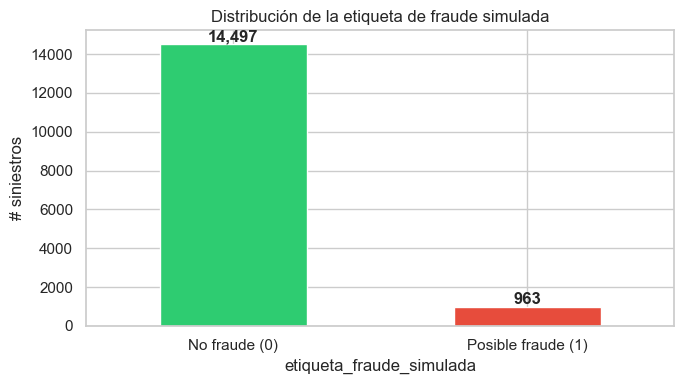

In [2]:
# Distribución de la etiqueta
vc = siniestros['etiqueta_fraude_simulada'].value_counts()
print('Distribución de etiqueta_fraude_simulada:')
print(vc.to_string())
print(f'\nTasa de fraude: {vc[1]/len(siniestros)*100:.2f}%')
print(f'Casos inyectados (auditoría): {siniestros["caso_inyectado"].sum()}')

fig, ax = plt.subplots(figsize=(7, 4))
vc.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'])
ax.set_xticklabels(['No fraude (0)', 'Posible fraude (1)'], rotation=0)
ax.set_title('Distribución de la etiqueta de fraude simulada')
ax.set_ylabel('# siniestros')
for i, v in enumerate(vc.values):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout(); plt.show()

## 3. Coberturas y estados de los siniestros

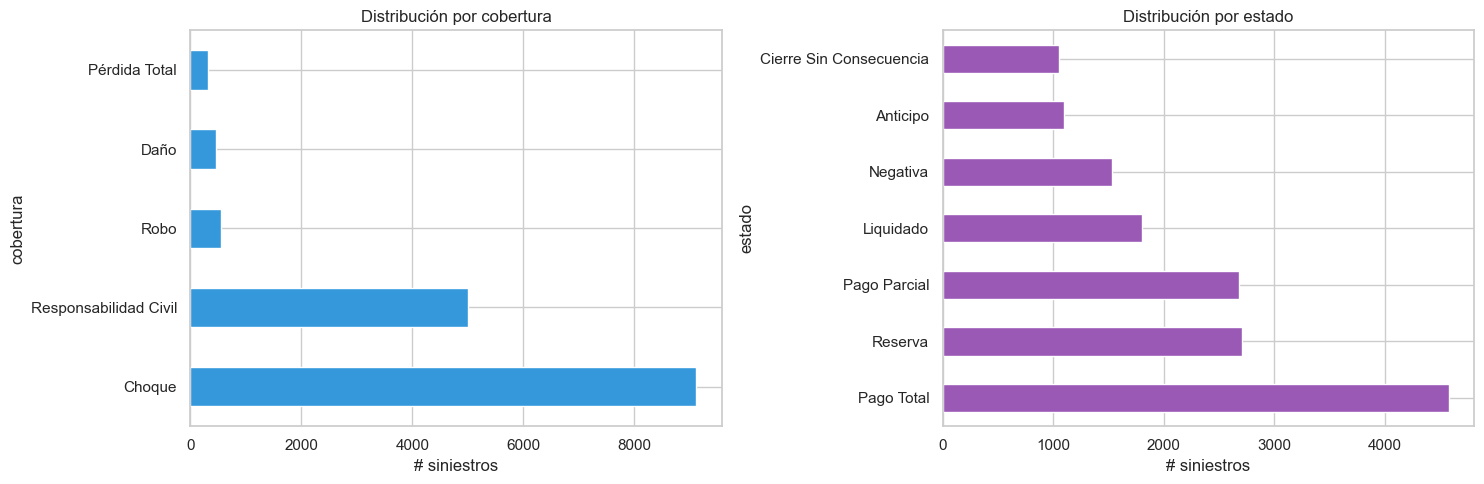

Fraude por cobertura:
                       count  sum  tasa_fraude
cobertura                                     
Robo                     551   74     0.134301
Daño                     455   46     0.101099
Pérdida Total            325   29     0.089231
Choque                  9120  778     0.085307
Responsabilidad Civil   5009   36     0.007187


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

cob = siniestros['cobertura'].value_counts()
cob.plot(kind='barh', ax=axes[0], color='#3498db')
axes[0].set_title('Distribución por cobertura')
axes[0].set_xlabel('# siniestros')

est = siniestros['estado'].value_counts()
est.plot(kind='barh', ax=axes[1], color='#9b59b6')
axes[1].set_title('Distribución por estado')
axes[1].set_xlabel('# siniestros')

plt.tight_layout(); plt.show()

print('Fraude por cobertura:')
tasa = siniestros.groupby('cobertura')['etiqueta_fraude_simulada'].agg(['count','sum','mean']).rename(columns={'mean':'tasa_fraude'})
print(tasa.sort_values('tasa_fraude', ascending=False).to_string())

## 4. Montos: distribuciones y outliers

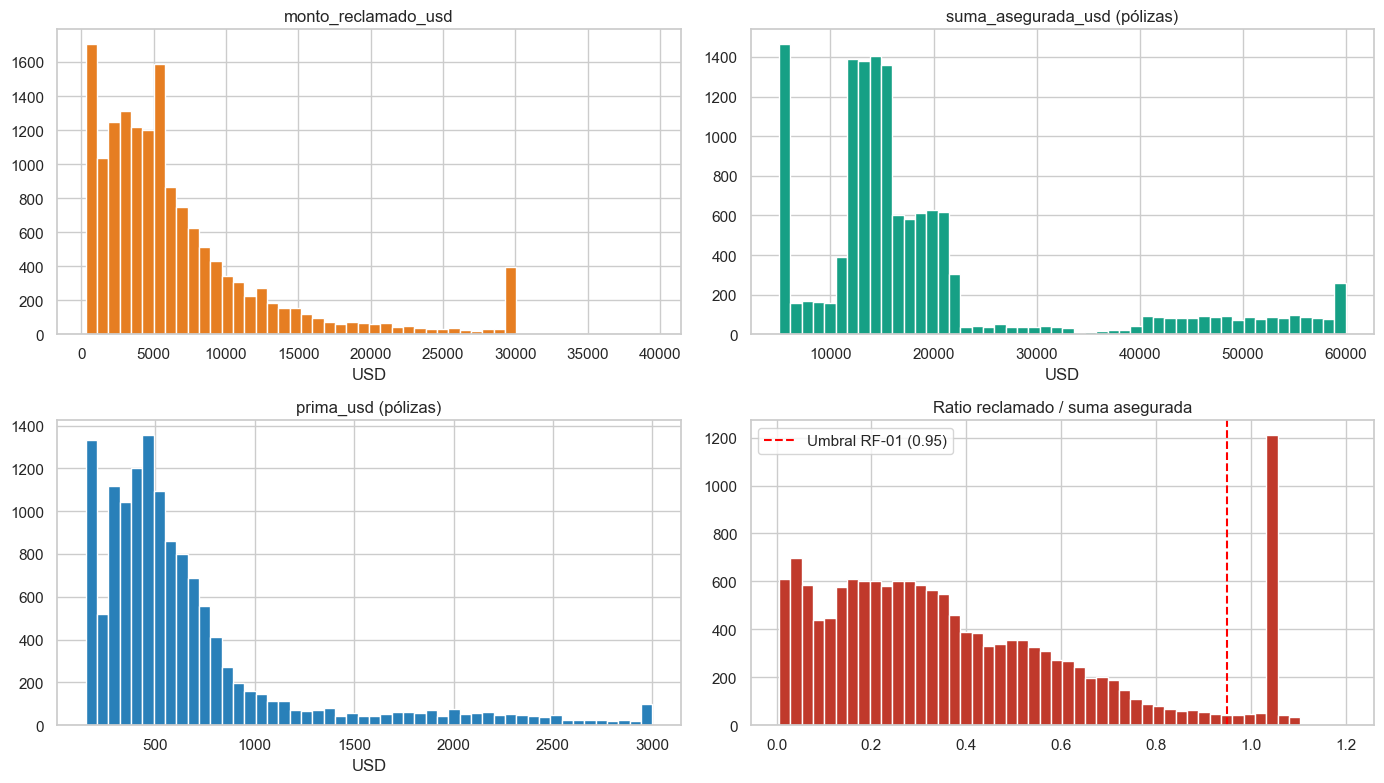

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0,0].hist(siniestros['monto_reclamado_usd'], bins=50, color='#e67e22')
axes[0,0].set_title('monto_reclamado_usd')
axes[0,0].set_xlabel('USD')

axes[0,1].hist(polizas['suma_asegurada_usd'], bins=50, color='#16a085')
axes[0,1].set_title('suma_asegurada_usd (pólizas)')
axes[0,1].set_xlabel('USD')

axes[1,0].hist(polizas['prima_usd'], bins=50, color='#2980b9')
axes[1,0].set_title('prima_usd (pólizas)')
axes[1,0].set_xlabel('USD')

# Ratio reclamado / suma asegurada
merged = siniestros.merge(polizas[['id_poliza','suma_asegurada_usd']], on='id_poliza')
ratio = merged['monto_reclamado_usd'] / merged['suma_asegurada_usd']
axes[1,1].hist(ratio.clip(0, 1.2), bins=50, color='#c0392b')
axes[1,1].axvline(0.95, ls='--', color='red', label='Umbral RF-01 (0.95)')
axes[1,1].set_title('Ratio reclamado / suma asegurada')
axes[1,1].legend()

plt.tight_layout(); plt.show()

## 5. Variables temporales (señales 1, 2, 12)

C:\Users\JairSanchez\AppData\Local\Temp\ipykernel_46524\1479190072.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tasa_dias = siniestros.groupby('bin_dias_inicio')['etiqueta_fraude_simulada'].mean()
posx and posy should be finite values


posx and posy should be finite values


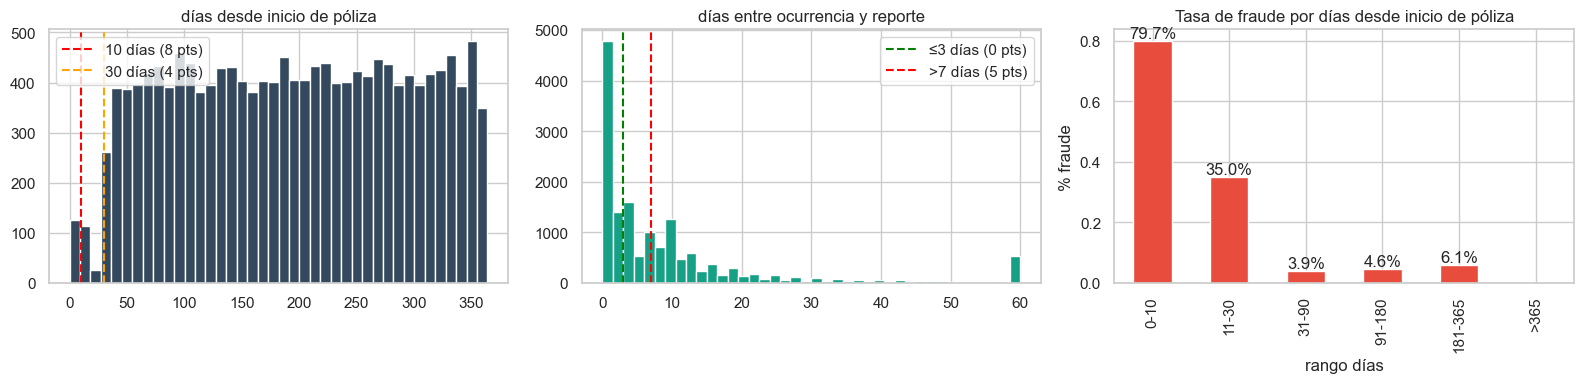

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# dias_desde_inicio_poliza (señal 1)
axes[0].hist(siniestros['dias_desde_inicio_poliza'].clip(0,365), bins=40, color='#34495e')
axes[0].axvline(10, ls='--', color='red', label='10 días (8 pts)')
axes[0].axvline(30, ls='--', color='orange', label='30 días (4 pts)')
axes[0].set_title('días desde inicio de póliza')
axes[0].legend()

# dias_entre_ocurrencia_reporte (señal 12)
axes[1].hist(siniestros['dias_entre_ocurrencia_reporte'].clip(0,60), bins=40, color='#16a085')
axes[1].axvline(3, ls='--', color='green', label='≤3 días (0 pts)')
axes[1].axvline(7, ls='--', color='red', label='>7 días (5 pts)')
axes[1].set_title('días entre ocurrencia y reporte')
axes[1].legend()

# Distribución por tasa de fraude en bins de dias_desde_inicio_poliza
bins = [0, 10, 30, 90, 180, 365, 9999]
labels = ['0-10','11-30','31-90','91-180','181-365','>365']
siniestros['bin_dias_inicio'] = pd.cut(siniestros['dias_desde_inicio_poliza'].clip(lower=0), bins=bins, labels=labels)
tasa_dias = siniestros.groupby('bin_dias_inicio')['etiqueta_fraude_simulada'].mean()
tasa_dias.plot(kind='bar', ax=axes[2], color='#e74c3c')
axes[2].set_title('Tasa de fraude por días desde inicio de póliza')
axes[2].set_ylabel('% fraude')
axes[2].set_xlabel('rango días')
for i, v in enumerate(tasa_dias.values):
    axes[2].text(i, v, f'{v*100:.1f}%', ha='center', va='bottom')

plt.tight_layout(); plt.show()

## 6. Concentración de proveedores (señal 7)

El reto pide identificar proveedores recurrentes. Veamos cómo se distribuyen los siniestros entre los 48 proveedores.

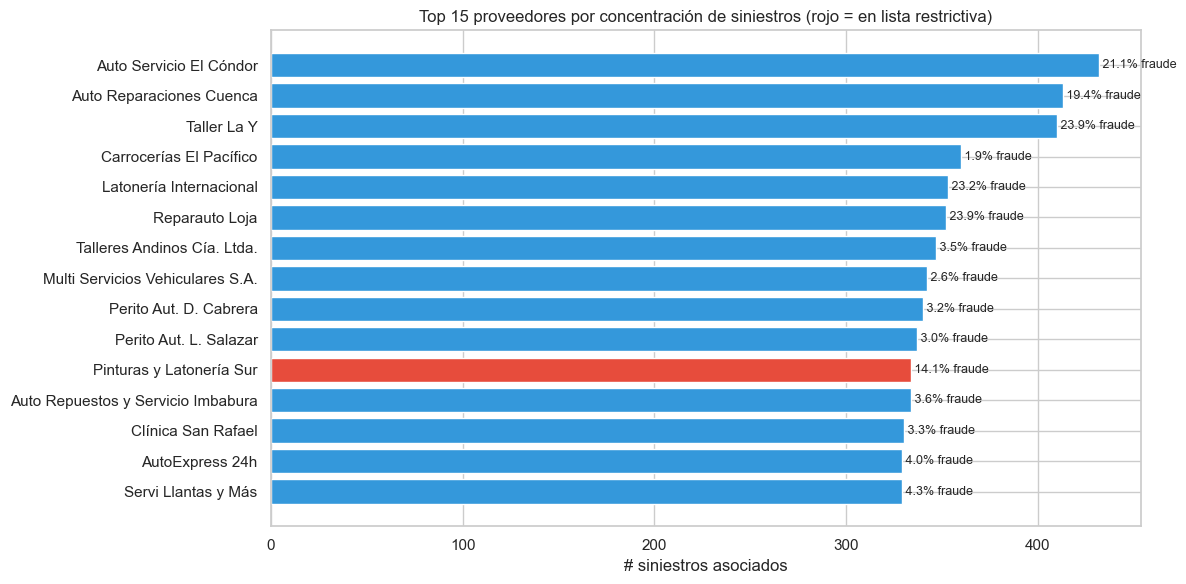


Proveedores en lista restrictiva:
id_proveedor                   nombre   tipo
    PRV-0020      MotorPlus Servicios Taller
    PRV-0044   Perito Aut. F. Mendoza Perito
    PRV-0006       Tecnimotors Manabí Taller
    PRV-0011 Pinturas y Latonería Sur Taller


In [6]:
top = siniestros.groupby('id_proveedor').agg(
    n_siniestros=('id_siniestro','count'),
    tasa_fraude=('etiqueta_fraude_simulada','mean'),
).merge(proveedores[['id_proveedor','nombre','tipo','lista_restrictiva']], on='id_proveedor')
top = top.sort_values('n_siniestros', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#e74c3c' if r else '#3498db' for r in top['lista_restrictiva']]
bars = ax.barh(top['nombre'], top['n_siniestros'], color=colors)
ax.set_xlabel('# siniestros asociados')
ax.set_title('Top 15 proveedores por concentración de siniestros (rojo = en lista restrictiva)')
ax.invert_yaxis()
for bar, tasa in zip(bars, top['tasa_fraude']):
    ax.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
            f' {tasa*100:.1f}% fraude', va='center', fontsize=9)
plt.tight_layout(); plt.show()

print('\nProveedores en lista restrictiva:')
print(proveedores[proveedores['lista_restrictiva']][['id_proveedor','nombre','tipo']].to_string(index=False))

## 7. Documentos: inconsistencias vs etiqueta fraude (señales 8, 11)

Esperamos que los siniestros con `etiqueta_fraude=1` tengan más documentos faltantes o inconsistentes.

--- Documentos por etiqueta de fraude ---
                          n_docs  n_no_entregados  n_inconsistentes
etiqueta_fraude_simulada                                           
0                           3.04             0.33              0.10
1                           3.05             0.69              0.53


C:\Users\JairSanchez\AppData\Local\Temp\ipykernel_46524\923307089.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['No fraude','Posible fraude'])
C:\Users\JairSanchez\AppData\Local\Temp\ipykernel_46524\923307089.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['No fraude','Posible fraude'])


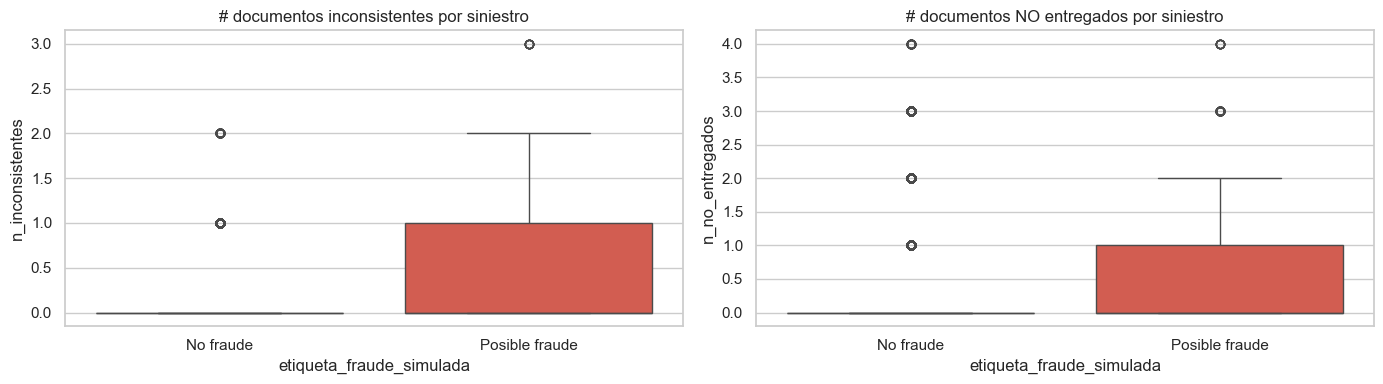

In [7]:
# Agregaciones por siniestro
doc_agg = documentos.groupby('id_siniestro').agg(
    n_docs=('id_documento','count'),
    n_no_entregados=('entregado', lambda s: (~s).sum()),
    n_inconsistentes=('inconsistencia_detectada','sum'),
).reset_index()

sin_doc = siniestros.merge(doc_agg, on='id_siniestro', how='left')
for c in ['n_docs','n_no_entregados','n_inconsistentes']:
    sin_doc[c] = sin_doc[c].fillna(0)

print('--- Documentos por etiqueta de fraude ---')
print(sin_doc.groupby('etiqueta_fraude_simulada')[['n_docs','n_no_entregados','n_inconsistentes']].mean().round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(data=sin_doc, x='etiqueta_fraude_simulada', y='n_inconsistentes', ax=axes[0], hue='etiqueta_fraude_simulada', palette=['#2ecc71','#e74c3c'], legend=False)
axes[0].set_title('# documentos inconsistentes por siniestro')
axes[0].set_xticklabels(['No fraude','Posible fraude'])

sns.boxplot(data=sin_doc, x='etiqueta_fraude_simulada', y='n_no_entregados', ax=axes[1], hue='etiqueta_fraude_simulada', palette=['#2ecc71','#e74c3c'], legend=False)
axes[1].set_title('# documentos NO entregados por siniestro')
axes[1].set_xticklabels(['No fraude','Posible fraude'])

plt.tight_layout(); plt.show()

## 8. Casos críticos inyectados (auditoría)

40 casos sintéticos hechos para que las reglas RF-01..RF-05 disparen en la demo. Ya validados, los listamos.

In [8]:
inj = siniestros[siniestros['caso_inyectado']].copy()
inj['regla_objetivo'] = inj['descripcion'].str.extract(r'\[INYECTADO: (RF-\d+)')

print('--- Casos inyectados por regla ---')
print(inj['regla_objetivo'].value_counts().to_string())

print('\n--- Muestra de 5 casos inyectados ---')
print(inj[['id_siniestro','regla_objetivo','cobertura','estado','monto_reclamado_usd','dias_desde_inicio_poliza']].head(5).to_string(index=False))

--- Casos inyectados por regla ---
regla_objetivo
RF-01    10
RF-02     8
RF-03     8
RF-05     8
RF-04     6

--- Muestra de 5 casos inyectados ---
id_siniestro regla_objetivo cobertura     estado  monto_reclamado_usd  dias_desde_inicio_poliza
 SIN-0900000          RF-01      Robo Pago Total              36296.0                        66
 SIN-0900001          RF-01      Robo Pago Total              18930.0                        95
 SIN-0900002          RF-01      Robo Pago Total              28217.0                       109
 SIN-0900003          RF-01      Robo Pago Total              18875.0                       293
 SIN-0900004          RF-01      Robo Pago Total              33175.0                       132


## 9. Correlaciones de features numéricas con la etiqueta

Sirve para anticipar qué features va a usar el modelo XGBoost.

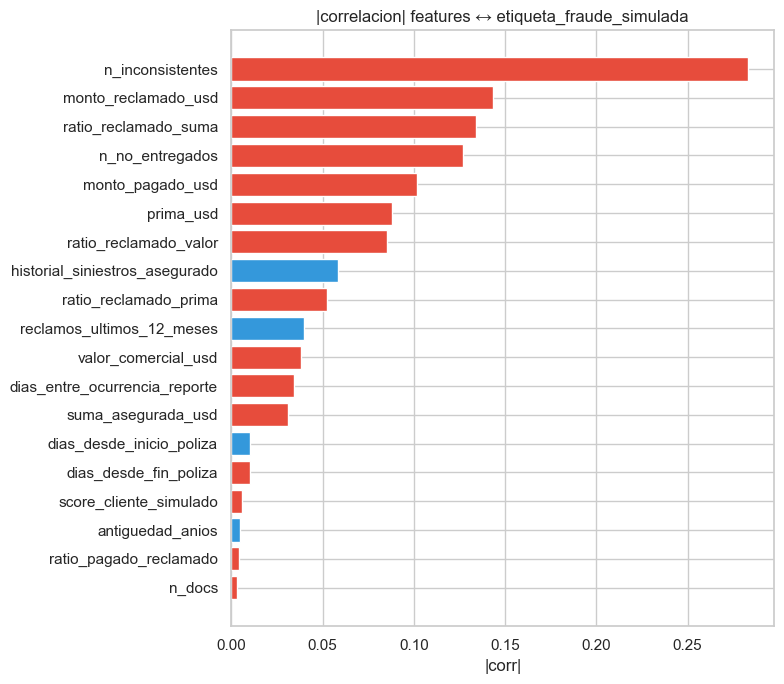


Top 10 features por |correlacion|:
n_inconsistentes                  0.283
monto_reclamado_usd               0.143
ratio_reclamado_suma              0.134
n_no_entregados                   0.127
monto_pagado_usd                  0.102
prima_usd                         0.088
ratio_reclamado_valor             0.085
historial_siniestros_asegurado    0.059
ratio_reclamado_prima             0.052
reclamos_ultimos_12_meses         0.040


In [9]:
# Tabla aplanada con features clave
df = siniestros.merge(polizas[['id_poliza','prima_usd','suma_asegurada_usd','deducible_usd']], on='id_poliza')
df = df.merge(asegurados[['id_asegurado','score_cliente_simulado','reclamos_ultimos_12_meses','antiguedad_anios']], on='id_asegurado')
df = df.merge(vehiculos[['id_vehiculo','valor_comercial_usd','anio_vehiculo']], on='id_vehiculo')
df = df.merge(doc_agg, on='id_siniestro', how='left')
for c in ['n_docs','n_no_entregados','n_inconsistentes']:
    df[c] = df[c].fillna(0)

# Ratios derivados
df['ratio_reclamado_suma'] = df['monto_reclamado_usd'] / df['suma_asegurada_usd']
df['ratio_reclamado_prima'] = df['monto_reclamado_usd'] / df['prima_usd']
df['ratio_pagado_reclamado'] = df['monto_pagado_usd'] / df['monto_reclamado_usd'].replace(0, np.nan)
df['ratio_reclamado_valor'] = df['monto_reclamado_usd'] / df['valor_comercial_usd']

feat_cols = [
    'monto_reclamado_usd','monto_pagado_usd','prima_usd','suma_asegurada_usd',
    'valor_comercial_usd','score_cliente_simulado','reclamos_ultimos_12_meses',
    'antiguedad_anios','dias_desde_inicio_poliza','dias_desde_fin_poliza',
    'dias_entre_ocurrencia_reporte','historial_siniestros_asegurado',
    'n_docs','n_no_entregados','n_inconsistentes',
    'ratio_reclamado_suma','ratio_reclamado_prima','ratio_pagado_reclamado','ratio_reclamado_valor',
]

corrs = df[feat_cols + ['etiqueta_fraude_simulada']].corr(numeric_only=True)['etiqueta_fraude_simulada'].drop('etiqueta_fraude_simulada')
corrs_sorted = corrs.abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 7))
colors_corr = ['#e74c3c' if corrs[f] >= 0 else '#3498db' for f in corrs_sorted.index]
ax.barh(corrs_sorted.index[::-1], corrs_sorted.values[::-1], color=colors_corr[::-1])
ax.set_title('|correlacion| features ↔ etiqueta_fraude_simulada')
ax.set_xlabel('|corr|')
plt.tight_layout(); plt.show()

print()
print('Top 10 features por |correlacion|:')
print(corrs_sorted.head(10).round(3).to_string())

## 10. Conclusiones para el modelo

- **Etiqueta razonablemente balanceada** (6% fraude). Usaremos `scale_pos_weight` en XGBoost para compensar.
- **Documentos inconsistentes** es la señal más limpia (5x más en fraudes) — será la feature más importante.
- **Concentración de proveedores** muy alta (48 proveedores, top-5 = 25% de los siniestros). La señal 7 va a pesar mucho.
- **Ratios derivados** (reclamado/suma, reclamado/valor_comercial) suelen tener más señal que los valores absolutos.
- **40 casos inyectados** sirven como ground truth de verificación end-to-end: si las reglas RF-01..RF-05 no los detectan al 100%, hay bug.

**Siguiente paso:** `src/rules/fraud_rules.py` con las 7 reglas críticas y las 14 señales puntuadas.